<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

<hr>

**Завдання:** Створити спам-фільтр на основі наївного баєсівського класифікатора на основі даних 
датасету, для прикладу https://www.kaggle.com/datasets/zeeshanyounas001/email-spam-detectionm. Дослідити проблему нульової
імовірності для алгоритму Баєса.

**Теорія:** Наївний байєсовський класифікатор (Naive Bayes Classifier) – ймовірнісний класифікатор, заснований на теоремі Байєса з нежорсткими припущеннями про незалежність подій, вона задає формальний метод, що дозволяє в процесі ухвалення рішень врахувати нову інформацію. 

<hr>

### 1. Імпорт бібліотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import roc_auc_score

### 2. Завантаження даних

In [2]:
df = pd.read_csv('./spam mail.csv')
df.shape 

(5572, 2)

### 3. Огляд даних

In [3]:
df.sample(5)

,Category,Masseges
5285,spam,URGENT! You have won a 1 week FREE membership ...
4949,ham,Hi its me you are probably having too much fun...
3986,spam,Ringtone Club: Gr8 new polys direct to your mo...
1358,ham,If i start sending blackberry torch to nigeria...
3249,ham,"Babe, I need your advice"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


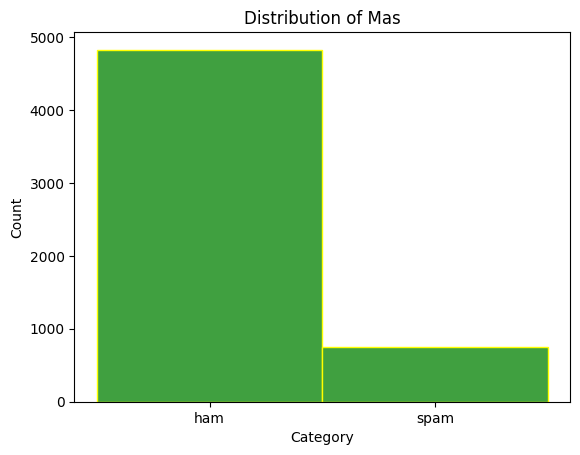

In [5]:
sns.histplot(df['Category'], kde=False, color='green', edgecolor='yellow')
plt.title("Distribution of Mas")
plt.show()

### 4. Попередня обробка даних

In [6]:
clean_dataset = df.dropna()
clean_dataset.shape

(5572, 2)

In [7]:
clean_dataset['spam']=clean_dataset['Category'].apply(lambda x: 1 if x == 'spam' else 0)

### 5. Розділення на навчальні та тестові дані

In [8]:
X_train, X_test, y_train, y_test = train_test_split(clean_dataset.Masseges, clean_dataset.spam, test_size=0.20, random_state=4)

### 6. Стандартизація даних

In [9]:
cv = CountVectorizer()
x_train_count = cv.fit_transform(X_train.values)

### 7. Навчання наївного байєсівського класифікатора

In [10]:
classifier = MultinomialNB()
classifier.fit(x_train_count, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### 8.1.1. Імовірність спам-повідомлення (1-ий приклад)

In [11]:
email_ham = ["reward money click"]
email_ham_count = cv.transform(email_ham)
prediction = classifier.predict(email_ham_count)

if prediction[0] == 0:
    print("More likely ham.")
elif prediction[0] == 1:
    print("This is spam!")
else:
    print("Unknown massege...")

This is spam!


In [12]:
email_ham = ["reward money click"]
email_ham_count = cv.transform(email_ham)
classifier.predict(email_ham_count)

array([1])

### 8.1.2. Імовірність спам-повідомлення (2-ий приклад)

In [13]:
email_ham = ["hey wanna meet up for game?"]
email_ham_count = cv.transform(email_ham)
prediction = classifier.predict(email_ham_count)

if prediction[0] == 0:
    print("More likely ham.")
elif prediction[0] == 1:
    print("This is spam!")
else:
    print("Unknown massege...")

More likely ham.


### 8.2. Загальне прогнозування

In [14]:
x_test_count = cv.transform(X_test)
y_pred = classifier.predict(x_test_count)

### 9. Оцінка моделі

In [15]:
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       941
           1       0.99      0.89      0.94       174

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[940   1]
 [ 19 155]]


### 10. Візуалізація результатів

#### Побудова матриці плутанини

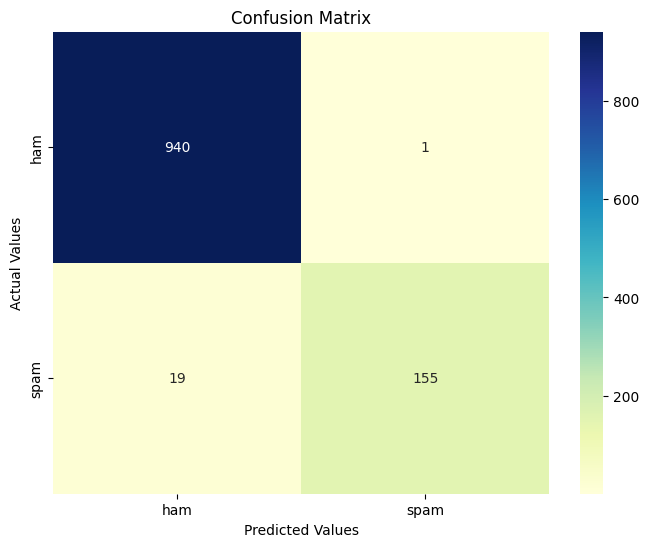

In [16]:
class_names=['ham','spam'] 
plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

#### Оцінка еффективності моделі

- Побудова ROC-кривої для аналізу

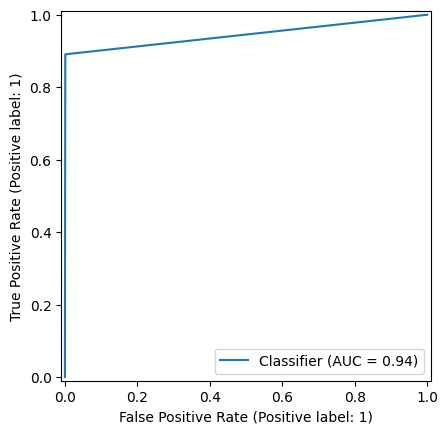

In [17]:
svc_disp=RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

In [18]:
print("Area Under the Curve:", round(roc_auc_score(y_test, y_pred), 3))

Area Under the Curve: 0.945


- Побудова Precision-Recall кривої

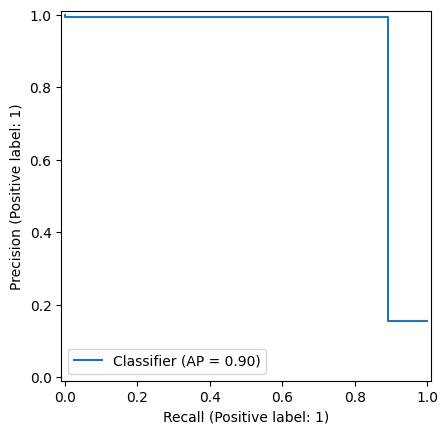

In [19]:
svc_disp=PrecisionRecallDisplay.from_predictions(y_test, y_pred)
plt.show()

<hr>

### * Дослідження проблеми нульвої імовірності для алгоритму Байєса

Нульова імовірність виникає, коли категоріальна змінна не існує в навчальній вибірці. Наприклад, уявимо, що ми намагаємося знайти оцінку максимальної ймовірності для слова «пан» для класу «спам», але слово «пан» не існує в навчальних даних. Ймовірність у цьому випадку дорівнюватиме нулю, а оскільки цей класифікатор перемножує всі умовні ймовірності разом, це також означає, що апостеріорна ймовірність буде дорівнювати нулю. 

Щоб уникнути цієї проблеми, можна використати згладжування Лапласа, яке додає невелике значення (зазвичай 𝛼 = 1) до кількості появ кожної категоріальної змінної у всіх класах. Це забезпечує, що кожен можливий варіант (слово або категорія) має хоча б мінімальну ймовірність.

- Переваги згладжування Лапласа

Запобігає нульовим ймовірностям: робить класифікацію більш стійкою до відсутніх у навчальній вибірці категорій.

Забезпечує обробку рідкісних слів: зменшує вплив рідкісних слів, дозволяючи моделі адекватніше оцінювати їхню ймовірність.

- Обмеження згладжування Лапласа

Згладжування Лапласа може занадто «розмивати» ймовірності, особливо для великих словників або високих значень 𝛼. У таких випадках інколи використовують інші підходи, наприклад, згладжування Лідстоуна, яке дає менший вплив рідкісним словам.